<a id="top"></a>
# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Aptos;text-align:center;display:fill;border-radius:5px;background-color:#00008B;overflow:hidden"><b>Actuarial Agents: Responsible AI Agent Teams for Actuarial Risk Prediction</b></div>

<div style="padding:16px;color:darkblue;margin:0;font-size:18px;font-family:Aptos;text-align:left;display:fill;border-radius:5px;background-color:white;overflow:hidden"><b>Author: Bart Custers</b></div>

<div style="padding:16px;color:darkblue;margin:0;font-size:18px;font-family:Aptos;text-align:left;display:fill;border-radius:5px;background-color:white;overflow:hidden"><i>MSc Thesis Artificial Intelligence, School of Computer Science, University of Hull</i></div>

<a id="top"></a>
# <div style="padding:20px;color:white;margin:0;font-size:24px;font-family:Aptos;text-align:left;display:fill;border-radius:5px;background-color:#00008B;overflow:hidden"><b>Evaluation: Notebook for deriving output statistics.</b></div>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = "C:/Users/bart_/Documents/Thesis/results/Workflow_run_stats.xlsx"

df = pd.read_excel(file_path)

# Inspect columns
print(df.columns)
df.head()

Index(['RunID', 'Timestamp', 'LLM_backend', 'Dataset', 'Workflow_succes',
       'Workflow_decision', 'Iterations', 'Adaptive_dataprep_succes',
       'Model_choice', 'Adaptive_model_code_succes', 'Belief_assessment',
       'TCAV_assessment', 'Fairness_assessment', 'RMSE', 'MAE',
       'Poisson_deviance', 'P(Workflow=OK)', 'Unnamed: 17'],
      dtype='object')


,RunID,Timestamp,LLM_backend,Dataset,Workflow_succes,Workflow_decision,Iterations,Adaptive_dataprep_succes,Model_choice,Adaptive_model_code_succes,Belief_assessment,TCAV_assessment,Fairness_assessment,RMSE,MAE,Poisson_deviance,P(Workflow=OK),Unnamed: 17
0,1,20260205_180357,Llama 2 7B,Original,1.0,APPROVE,1.0,1.0,GLM,0.0,NO_ISSUES,NO_ISSUES,NO_ISSUES,0.886779,0.232322,0.947699,0.7006,NaN
1,2,20260205_181231,Llama 2 7B,Original,1.0,APPROVE,1.0,1.0,GLM,0.0,MINOR_ISSUES,NO_ISSUES,NO_ISSUES,0.886779,0.232322,0.947699,0.7079,NaN
2,3,20260205_183138,Llama 2 7B,Original,1.0,APPROVE,1.0,1.0,GLM,0.0,NO_ISSUES,NO_ISSUES,MINOR_ISSUES,0.886779,0.232322,0.947699,0.7024,NaN
3,4,20260205_195843,Llama 2 7B,Original,1.0,CONSULT_ACTUARY,1.0,1.0,GLM,0.0,NO_ISSUES,NO_ISSUES,MINOR_ISSUES,0.886779,0.232322,0.947699,0.7471,NaN
4,5,20260205_201858,Llama 2 7B,Original,1.0,CONSULT_ACTUARY,1.0,0.0,GLM,0.0,SEVERE_ISSUES,MINOR_ISSUES,MINOR_ISSUES,0.886779,0.232322,0.947699,0.7085,NaN


In [3]:
df_original = df[df["Dataset"] == "Original"]

### **1. Task Success Rate per LLM**

    LLM_backend  Success_rate
0    Llama 2 7B      0.800000
1  Llama 3.1 8B      0.909091
2    Qwen2.5 7B      0.800000


C:\Users\bart_\AppData\Local\Temp\ipykernel_26748\520382010.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_original["Workflow_succes"] = df_original["Workflow_succes"].astype(int)


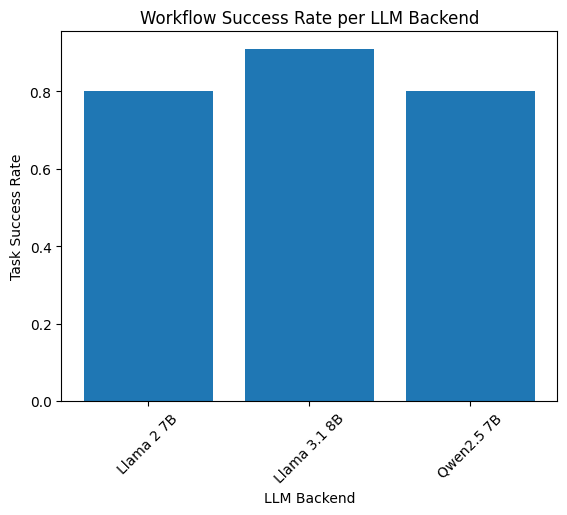

In [5]:
# Ensure Workflow_success is numeric (0/1 or True/False)
df_original["Workflow_succes"] = df_original["Workflow_succes"].astype(int)

# Compute success rate per LLM backend
success_rate = (
    df_original.groupby("LLM_backend")["Workflow_succes"]
    .mean()
    .reset_index()
)

success_rate.rename(columns={"Workflow_succes": "Success_rate"}, inplace=True)

print(success_rate)

# Plot success rate
plt.figure()
plt.bar(success_rate["LLM_backend"], success_rate["Success_rate"])
plt.xlabel("LLM Backend")
plt.ylabel("Task Success Rate")
plt.title("Workflow Success Rate per LLM Backend")
plt.xticks(rotation=45)
plt.show()

### **2. Workflow outcome per LLM**

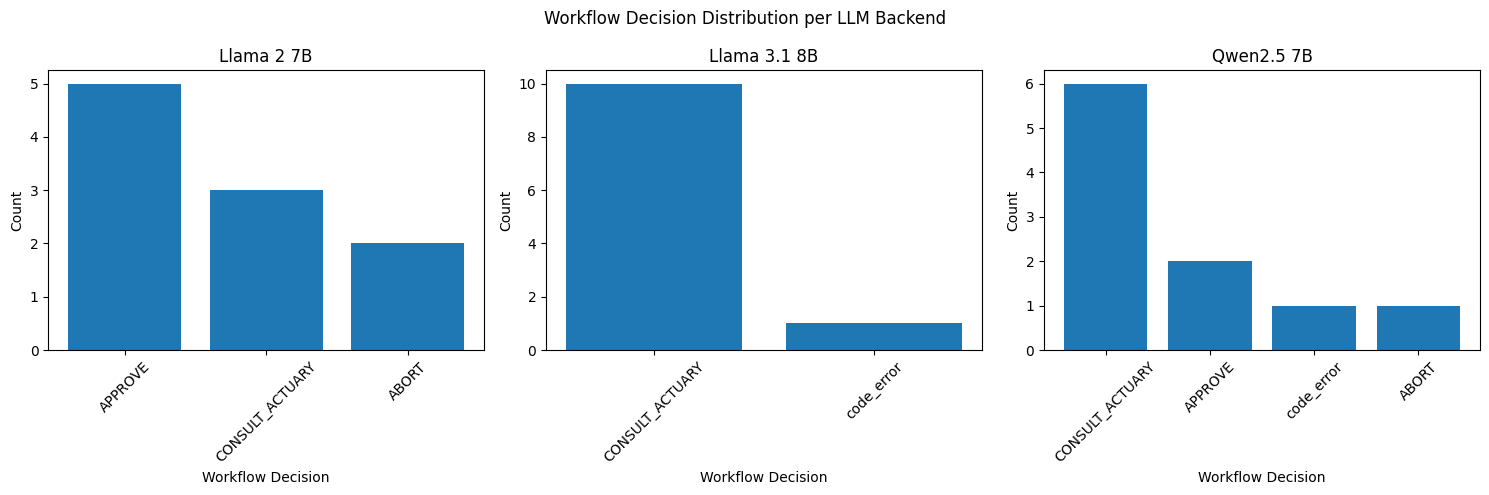

In [8]:
llms = df_original["LLM_backend"].unique()

fig, axes = plt.subplots(1, len(llms), figsize=(15,5))

for i, backend in enumerate(llms):
    subset = df_original[df_original["LLM_backend"] == backend]
    
    counts = subset["Workflow_decision"].value_counts()
    
    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(backend)
    axes[i].set_xlabel("Workflow Decision")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle("Workflow Decision Distribution per LLM Backend")
plt.tight_layout()
plt.show()

### **3. Model choice per LLM**

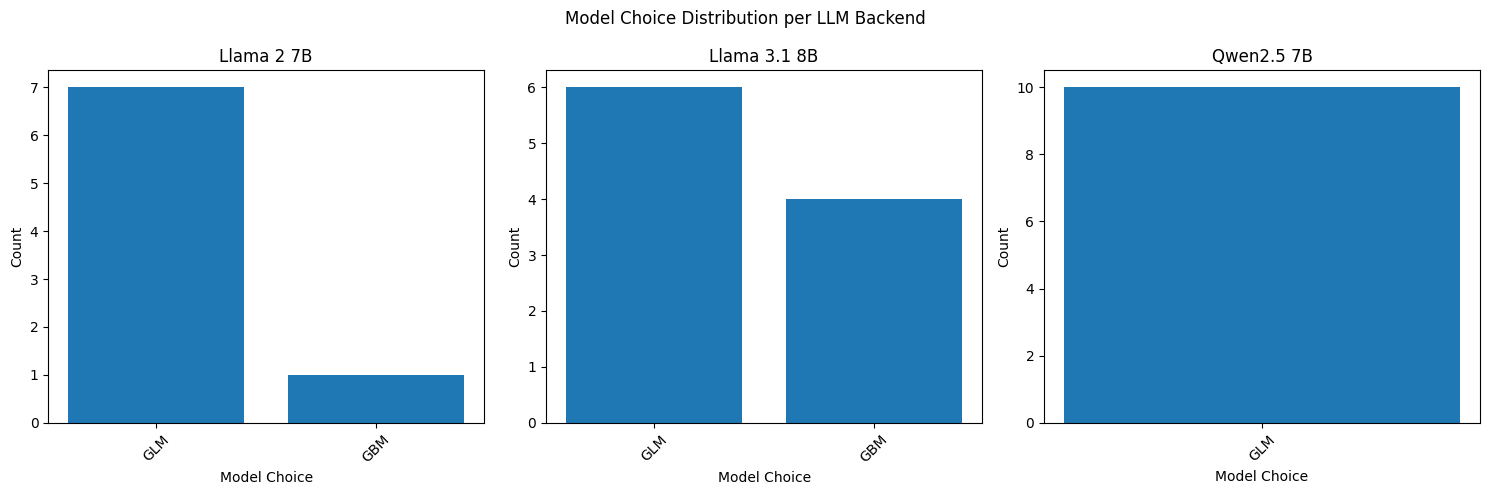

In [9]:
fig, axes = plt.subplots(1, len(llms), figsize=(15,5))

for i, backend in enumerate(llms):
    subset = df_original[df_original["LLM_backend"] == backend]
    
    counts = subset["Model_choice"].value_counts()
    
    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(backend)
    axes[i].set_xlabel("Model Choice")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle("Model Choice Distribution per LLM Backend")
plt.tight_layout()
plt.show()

### **4. Model RMSE per LLM**

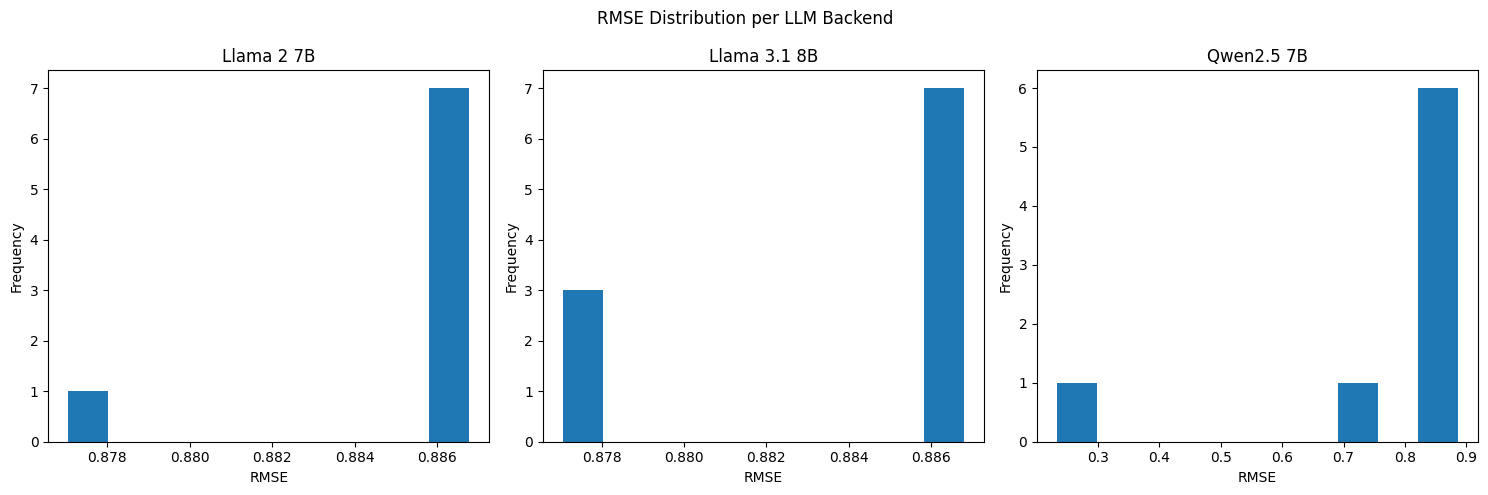

In [11]:
fig, axes = plt.subplots(1, len(llms), figsize=(15,5))

for i, backend in enumerate(llms):
    subset = df_original[df_original["LLM_backend"] == backend]
    
    axes[i].hist(subset["RMSE"], bins=10)
    axes[i].set_title(backend)
    axes[i].set_xlabel("RMSE")
    axes[i].set_ylabel("Frequency")

fig.suptitle("RMSE Distribution per LLM Backend")
plt.tight_layout()
plt.show()

### **5. Code generation success**

C:\Users\bart_\AppData\Local\Temp\ipykernel_26748\3562942368.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_original["Adaptive_dataprep_succes"] = pd.to_numeric(df_original["Adaptive_dataprep_succes"], errors="coerce")
C:\Users\bart_\AppData\Local\Temp\ipykernel_26748\3562942368.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_original["Adaptive_model_code_succes"] = pd.to_numeric(df_original["Adaptive_model_code_succes"], errors="coerce")


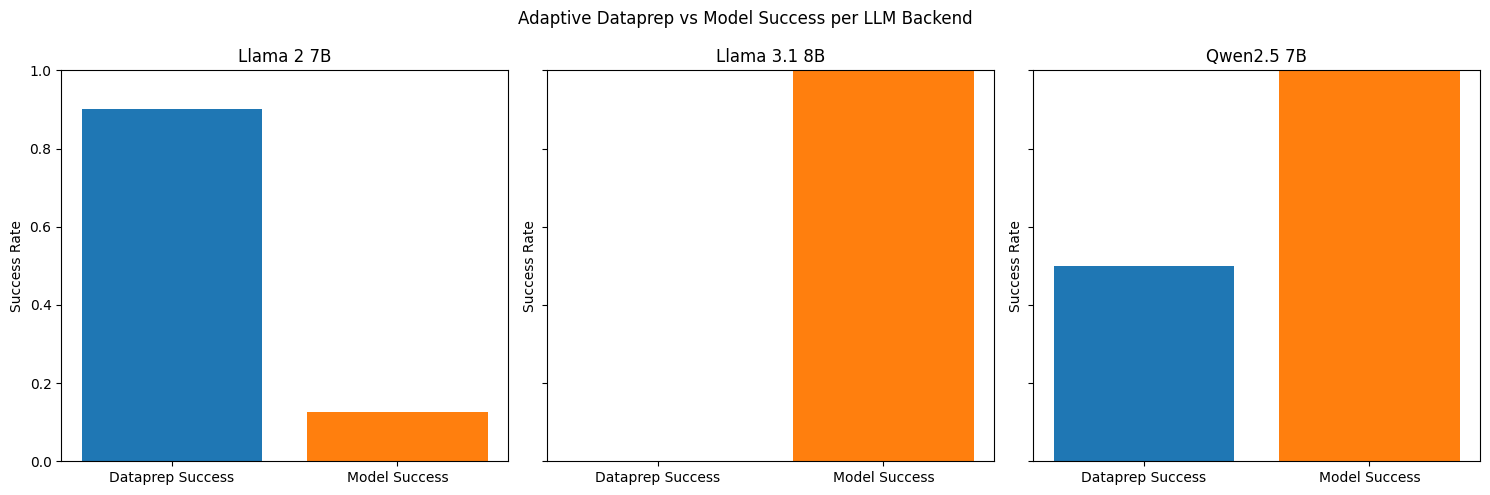

In [16]:
# Ensure success columns are numeric (0/1)
df_original["Adaptive_dataprep_succes"] = pd.to_numeric(df_original["Adaptive_dataprep_succes"], errors="coerce")
df_original["Adaptive_model_code_succes"] = pd.to_numeric(df_original["Adaptive_model_code_succes"], errors="coerce")

llms = df_original["LLM_backend"].unique()

fig, axes = plt.subplots(1, len(llms), figsize=(15,5), sharey=True)

# If only one LLM exists, make axes iterable
if len(llms) == 1:
    axes = [axes]

for i, backend in enumerate(llms):
    subset = df_original[df_original["LLM_backend"] == backend]
    
    # Compute success rates
    dataprep_rate = subset["Adaptive_dataprep_succes"].mean()
    model_rate = subset["Adaptive_model_code_succes"].mean()
    
    axes[i].bar(
        "Dataprep Success",
        dataprep_rate,
        color="tab:blue"
    )
    
    axes[i].bar(
        "Model Success",
        model_rate,
        color="tab:orange"
    )
    
    axes[i].set_title(backend)
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel("Success Rate")

fig.suptitle("Adaptive Dataprep vs Model Success per LLM Backend")
plt.tight_layout()
plt.show()

### **6. Number of iterations per run, per LLM backend**

C:\Users\bart_\AppData\Local\Temp\ipykernel_26748\1368366157.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_original["Iterations"] = pd.to_numeric(df_original["Iterations"], errors="coerce")


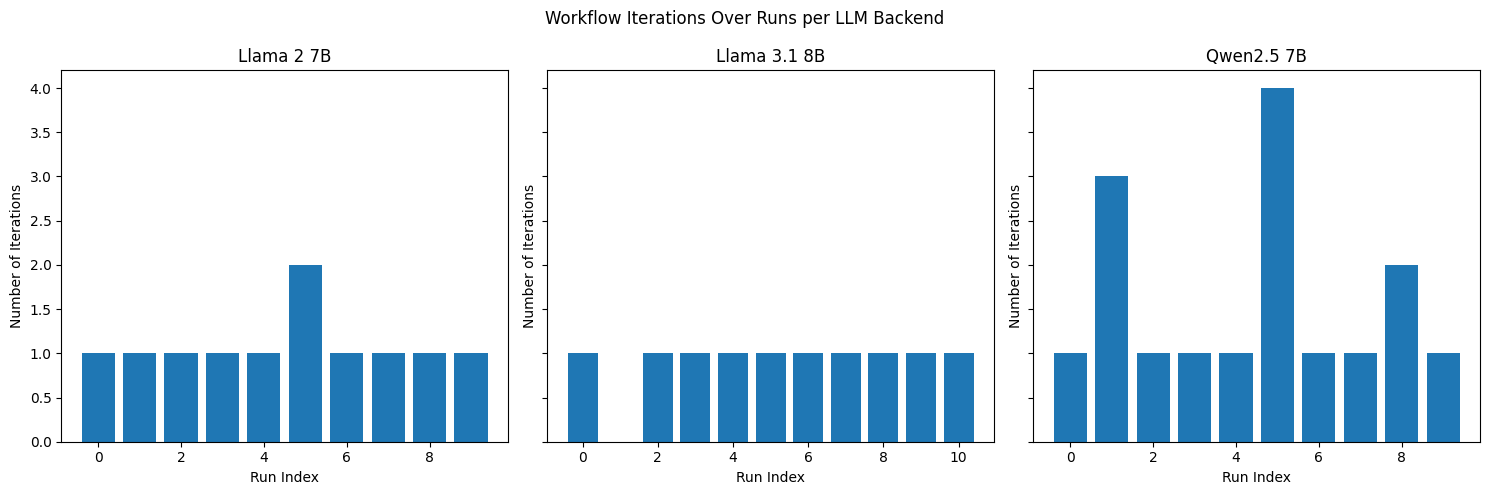

In [18]:
df_original["Iterations"] = pd.to_numeric(df_original["Iterations"], errors="coerce")

llms = df_original["LLM_backend"].unique()

fig, axes = plt.subplots(1, len(llms), figsize=(15,5), sharey=True)

# If only one LLM exists
if len(llms) == 1:
    axes = [axes]

for i, backend in enumerate(llms):
    subset = df_original[df_original["LLM_backend"] == backend].reset_index(drop=True)
    
    axes[i].bar(subset.index, subset["Iterations"])
    axes[i].set_title(backend)
    axes[i].set_xlabel("Run Index")
    axes[i].set_ylabel("Number of Iterations")

fig.suptitle("Workflow Iterations Over Runs per LLM Backend")

plt.tight_layout()
plt.show()

### **7. BN uncertainty outcome**

C:\Users\bart_\AppData\Local\Temp\ipykernel_26748\3845382055.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_original["P(Workflow=OK)"] = pd.to_numeric(df_original["P(Workflow=OK)"], errors="coerce")


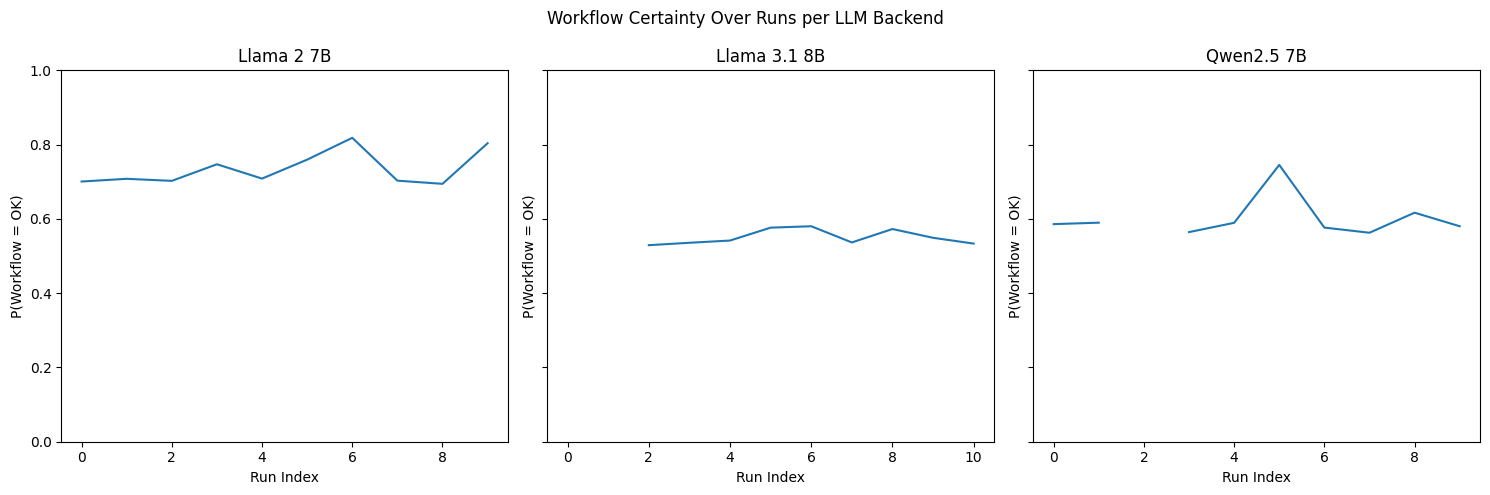

In [19]:
# Ensure numeric (handles NaN safely)
df_original["P(Workflow=OK)"] = pd.to_numeric(df_original["P(Workflow=OK)"], errors="coerce")

llms = df_original["LLM_backend"].unique()

fig, axes = plt.subplots(1, len(llms), figsize=(15,5), sharey=True)

# Handle single LLM case
if len(llms) == 1:
    axes = [axes]

for i, backend in enumerate(llms):
    subset = df_original[df_original["LLM_backend"] == backend].reset_index(drop=True)
    
    axes[i].plot(subset.index, subset["P(Workflow=OK)"])
    axes[i].set_title(backend)
    axes[i].set_xlabel("Run Index")
    axes[i].set_ylabel("P(Workflow = OK)")
    axes[i].set_ylim(0, 1)

fig.suptitle("Workflow Certainty Over Runs per LLM Backend")

plt.tight_layout()
plt.show()